# Description: CPM Analyses Evaluation - Figure 7

This notebook builds Figure 7 for the evaluation dataset.
It summarizes CPM prediction accuracy, derives consensus edge models, visualizes session-1 model structure, and generates observed-vs-predicted scatter plots used in the final multi-panel figure.


In [1]:
import os
import os.path as osp

import holoviews as hv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import panel as pn
import seaborn as sns
import xarray as xr
from nilearn.connectome import vec_to_sym_matrix
from scipy.stats import pearsonr, spearmanr
from tqdm.notebook import tqdm

from utils.basics import ATLASES_DIR, CODE_DIR
from utils.basics import get_altas_info
from utils.dashboard import get_static_report
from utils.fc_matrices import hvplot_fc

# Initialize Panel once so Pane objects render correctly in this notebook.
pn.extension()


/data/SFIMJGC_HCP7T/Apps/envs/generic_2025a/lib/python3.12/site-packages/nxviz/__init__.py:18: UserWarning: 
nxviz has a new API! Version 0.7.4 onwards, the old class-based API is being
deprecated in favour of a new API focused on advancing a grammar of network
graphics. If your plotting code depends on the old API, please consider
pinning nxviz at version 0.7.4, as the new API will break your old code.

To check out the new API, please head over to the docs at
https://ericmjl.github.io/nxviz/ to learn more. We hope you enjoy using it!

(This deprecation message will go away in version 1.0.)

  warnings.warn(


# Load Dataset and Parcellation Information

Set analysis constants (dataset, behavior, number of CPM iterations, consensus threshold), then load ROI/network metadata for the Power264 evaluation atlas.


In [2]:
# Global analysis configuration used across all figure panels.
CPM_NUM_ITERS                 = 100
CPM_MODEL_CONSENSUS_THRESHOLD = 0.9
BEHAVIOR      = 'nihcog_fluidcomp'
DATASET       = 'evaluation'

# Atlas metadata for the selected dataset.
ATLAS_NAME = f'Power264-{DATASET}'
ATLAS_DIR = osp.join(ATLASES_DIR,ATLAS_NAME)


In [3]:
# Load ROI metadata and network color mapping for plotting.
roi_info_df, power264_nw_cmap = get_altas_info(ATLAS_DIR,ATLAS_NAME)
roi_idxs = roi_info_df.set_index(['ROI_Name', 'ROI_ID', 'Hemisphere', 'Network']).index

Nrois = roi_info_df.shape[0]
# Number of unique undirected edges in an ROI-by-ROI symmetric matrix.
Ncons = int(((Nrois) * (Nrois-1))/2)


++ INFO [get_nw_cmap]: Gathering ROI information from file /data/SFIMJGC_HCP7T/BCBL2024/atlases/Power264-evaluation/Power264-evaluation.roi_info.csv
++ INFO: Number of ROIs = 203 | Number of Connections = 20503


# Load Prediction Accuracy

Read all cached CPM runs across sessions, preprocessing pipelines, and m-NORDIC settings.
For each run, compute Pearson and Spearman correlations between observed and predicted scores.


In [4]:
accuracy_dict = {'Pearson' :None,
                 'Spearman':None}

# Iterate over every CPM scenario and collect per-iteration prediction accuracy.
for TRAINING_SES in tqdm(['ses-1','ses-2'], desc='Session'):
    for pp in ['ALL_Basic','ALL_GS','ALL_Tedana-fastica']:
        for NORDIC in ['off','on']:
            for i in tqdm(range(CPM_NUM_ITERS), desc=f'{TRAINING_SES}|{pp}|{NORDIC}', leave=False):
                zpi = str(i).zfill(5)
                try:
                    path = osp.join(CODE_DIR,'notebooks','cache','cpm',f'{TRAINING_SES}_{pp}_NORDIC_{NORDIC}',f'cpm_{BEHAVIOR}_rep-{zpi}.pkl')
                    aux = pd.read_pickle(path)
                except:
                    print(f'{TRAINING_SES}_{pp}_NORDIC_{NORDIC}',f'cpm_{BEHAVIOR}_rep-{zpi}.pkl is not available')
                # Accuracy metrics used in the manuscript and companion figures.
                r,_ = pearsonr(aux['behav_obs_pred']['nihcog_fluidcomp observed'].values,aux['behav_obs_pred']['nihcog_fluidcomp predicted (glm)'].values)
                s,_ = spearmanr(aux['behav_obs_pred']['nihcog_fluidcomp observed'].values,aux['behav_obs_pred']['nihcog_fluidcomp predicted (glm)'].values)
                # Store one row per iteration for downstream grouped plotting.
                if accuracy_dict['Pearson'] is None:
                    accuracy_dict['Pearson'] = pd.DataFrame({'Pre-processing':[pp],'Session':[TRAINING_SES],'Iteration':[i],'NORDIC':[NORDIC],'Accuracy':[r]})
                else:
                    accuracy_dict['Pearson'] = pd.concat([accuracy_dict['Pearson'],pd.DataFrame({'Pre-processing':[pp],'Session':[TRAINING_SES],'Iteration':[i],'NORDIC':[NORDIC],'Accuracy':[r]})], ignore_index=True)

                if accuracy_dict['Spearman'] is None:
                    accuracy_dict['Spearman'] = pd.DataFrame({'Pre-processing':[pp],'Session':[TRAINING_SES],'Iteration':[i],'NORDIC':[NORDIC],'Accuracy':[s]})
                else:
                    accuracy_dict['Spearman'] = pd.concat([accuracy_dict['Spearman'],pd.DataFrame({'Pre-processing':[pp],'Session':[TRAINING_SES],'Iteration':[i],'NORDIC':[NORDIC],'Accuracy':[s]})], ignore_index=True)


Session:   0%|          | 0/2 [00:00<?, ?it/s]

ses-1|ALL_Basic|off:   0%|          | 0/100 [00:00<?, ?it/s]

ses-1|ALL_Basic|on:   0%|          | 0/100 [00:00<?, ?it/s]

ses-1|ALL_GS|off:   0%|          | 0/100 [00:00<?, ?it/s]

ses-1|ALL_GS|on:   0%|          | 0/100 [00:00<?, ?it/s]

...

ses-2|ALL_Basic|on:   0%|          | 0/100 [00:00<?, ?it/s]

ses-2|ALL_GS|off:   0%|          | 0/100 [00:00<?, ?it/s]

ses-2|ALL_GS|on:   0%|          | 0/100 [00:00<?, ?it/s]

ses-2|ALL_Tedana-fastica|off:   0%|          | 0/100 [00:00<?, ?it/s]

ses-2|ALL_Tedana-fastica|on:   0%|          | 0/100 [00:00<?, ?it/s]

### Harmonize Column Naming

Rename `NORDIC` to `m-NORDIC` so labels match the manuscript and other figure notebooks.


In [5]:
# Keep naming consistent with figure captions and manuscript text.
accuracy_dict['Pearson'].columns = [c.replace('NORDIC','m-NORDIC') for c in accuracy_dict['Pearson'].columns]


### Panel (a): Session 1 Accuracy

Create and save the session-1 bar/swarm summary plot of CPM accuracy across preprocessing pipelines and m-NORDIC settings.


In [6]:
# Filter to session 1, then render grouped CPM accuracy summary.
session01_accuracy = get_static_report(accuracy_dict['Pearson'].set_index(['Session']).loc['ses-1'].reset_index(drop=True),
                         None,
                         'Accuracy',
                         hue='Pre-processing',
                         x='m-NORDIC', 
                         remove_outliers_from_statistics=False,
                         remove_outliers_from_swarm=False,show_points=True, 
                         stat_test='Mann-Whitney', show_stats=True)
# Add panel label used in the composite figure.
session01_accuracy.suptitle("(a) Prediction Accuracy for Session 1", x=0.01, y=1.05, ha="left", fontsize=20);
# Improve layout
plt.tight_layout()
# Save to disk
out_png = "./figures/pBOLD_Figure07_a.png"
session01_accuracy.figure.savefig( out_png, dpi=300, bbox_inches="tight",   # critical: captures cbar outside default figure bounds
    pad_inches=0.05)
print(f"Saved: {out_png}")


Saved: ./figures/pBOLD_Figure07_a.png


<Figure size 640x480 with 0 Axes>

### Panel (b): Session 2 Accuracy

Create and save the session-2 bar/swarm summary plot of CPM accuracy across preprocessing pipelines and m-NORDIC settings.


In [7]:
# Filter to session 2, then render grouped CPM accuracy summary.
session02_accuracy = get_static_report(accuracy_dict['Pearson'].set_index(['Session']).loc['ses-2'].reset_index(drop=True),
                         None,
                         'Accuracy',
                         hue='Pre-processing',
                         x='m-NORDIC', 
                         remove_outliers_from_statistics=False,
                         remove_outliers_from_swarm=False,show_points=True, 
                         stat_test='Mann-Whitney', show_stats=True)
# Add panel label used in the composite figure.
session02_accuracy.suptitle("(b) Prediction Accuracy for Session 2", x=0.01, y=1.05, ha="left", fontsize=20, fontname='sans-serif');
# Improve layout
plt.tight_layout()
# Save to disk
out_png = "./figures/pBOLD_Figure07_b.png"
session02_accuracy.figure.savefig( out_png, dpi=300, bbox_inches="tight",   # critical: captures cbar outside default figure bounds
    pad_inches=0.05)
print(f"Saved: {out_png}")


Saved: ./figures/pBOLD_Figure07_b.png


<Figure size 640x480 with 0 Axes>

# Create Panels c - e | CPM Consensus Models

## Load Individual CPM Models and Derive Iteration-Level Consensus Masks

For each session/pipeline/m-NORDIC scenario, load every CPM iteration and convert positive/negative edge fractions into binary consensus masks using the configured threshold.


In [8]:
models_to_vis    = {}
model_consensus,num_edges_toshow,model_consensus_to_plot  = {},{},{}
# Build per-iteration consensus masks for all sessions and preprocessing scenarios.
for TRAINING_SES in tqdm(['ses-1','ses-2'], desc='Session'):
    for pp in ['ALL_Basic','ALL_GS','ALL_Tedana-fastica']:
        for NORDIC in ['off','on']:
            for n_iter in tqdm(range(CPM_NUM_ITERS), desc=f'{TRAINING_SES}|{pp}|{NORDIC}', leave=False):
                # Load CPM outcomes for a given pipeline and CPM iteration
                zpi = str(n_iter).zfill(5)
                try:
                    path = osp.join(CODE_DIR,'notebooks','cache','cpm',f'{TRAINING_SES}_{pp}_NORDIC_{NORDIC}',f'cpm_{BEHAVIOR}_rep-{zpi}.pkl')
                    aux = pd.read_pickle(path)
                except:
                    print(f'{TRAINING_SES}_{pp}_NORDIC_{NORDIC}',f'cpm_{BEHAVIOR}_rep-{zpi}.pkl')
                # Locate the CPM model
                this_iter_output = aux['models']
                # Get the positive and negative connections in the model
                models_to_vis[TRAINING_SES,pp,NORDIC,n_iter,'pos'] = this_iter_output['pos'].mean(axis=0)
                models_to_vis[TRAINING_SES,pp,NORDIC,n_iter,'neg'] = this_iter_output['neg'].mean(axis=0)
                # Create consensus model (meaning keep only those above the threshold)
                for tail in ['pos','neg']:
                    edge_frac                       = models_to_vis[(TRAINING_SES,pp,NORDIC,n_iter,tail)]
                    model_consensus[(TRAINING_SES,pp,NORDIC,n_iter,tail)]  = (edge_frac>=CPM_MODEL_CONSENSUS_THRESHOLD).astype(int)
                    num_edges_toshow[(TRAINING_SES,pp,NORDIC,n_iter,tail)] = model_consensus[(TRAINING_SES,pp,NORDIC,n_iter,tail)].sum()


Session:   0%|          | 0/2 [00:00<?, ?it/s]

ses-1|ALL_Basic|off:   0%|          | 0/100 [00:00<?, ?it/s]

ses-1|ALL_Basic|on:   0%|          | 0/100 [00:00<?, ?it/s]

ses-1|ALL_GS|off:   0%|          | 0/100 [00:00<?, ?it/s]

ses-1|ALL_GS|on:   0%|          | 0/100 [00:00<?, ?it/s]

...

ses-2|ALL_Basic|on:   0%|          | 0/100 [00:00<?, ?it/s]

ses-2|ALL_GS|off:   0%|          | 0/100 [00:00<?, ?it/s]

ses-2|ALL_GS|on:   0%|          | 0/100 [00:00<?, ?it/s]

ses-2|ALL_Tedana-fastica|off:   0%|          | 0/100 [00:00<?, ?it/s]

ses-2|ALL_Tedana-fastica|on:   0%|          | 0/100 [00:00<?, ?it/s]

### Average Consensus Masks Across Iterations

For each scenario, average the binary consensus masks across iterations to obtain a final edge-selection probability matrix for positive and negative CPM models.


In [9]:
final_model = {}
for TRAINING_SES in tqdm(['ses-1','ses-2'],desc='Session'):
    for pp in ['ALL_Basic','ALL_GS','ALL_Tedana-fastica']:
        for NORDIC in ['off','on']:
            # Create empty holders for the final models
            final_model[(TRAINING_SES,pp,NORDIC,'pos')] = np.zeros(Ncons)
            final_model[(TRAINING_SES,pp,NORDIC,'neg')] = np.zeros(Ncons)
            # For both positive and negative models separately
            for tail in ['pos','neg']:
                for n_iter in tqdm(range(CPM_NUM_ITERS), desc=f'{TRAINING_SES}|{pp}|{NORDIC}', leave=False):
                    # Final model is the average of all the consensus models for a given scenario
                    final_model[(TRAINING_SES,pp,NORDIC,tail)] += model_consensus[(TRAINING_SES,pp,NORDIC,n_iter,tail)]
                # Divide the sum of consensus models by the number of models loaded (ie., number of iterations)
                final_model[(TRAINING_SES,pp,NORDIC,tail)] = final_model[(TRAINING_SES,pp,NORDIC,tail)] / CPM_NUM_ITERS
                # Prepare the model for plotting with hvplot_fc
                final_model[(TRAINING_SES,pp,NORDIC,tail)] = pd.DataFrame(vec_to_sym_matrix(final_model[(TRAINING_SES,pp,NORDIC,tail)],diagonal=np.zeros(Nrois)),
                                       index = roi_info_df.set_index(['ROI_ID','ROI_Name','Hemisphere','Network','RGB']).index,
                                       columns= roi_info_df.set_index(['ROI_ID','ROI_Name','Hemisphere','Network','RGB']).index)


Session:   0%|          | 0/2 [00:00<?, ?it/s]

ses-1|ALL_Basic|off:   0%|          | 0/100 [00:00<?, ?it/s]

ses-1|ALL_Basic|off:   0%|          | 0/100 [00:00<?, ?it/s]

ses-1|ALL_Basic|on:   0%|          | 0/100 [00:00<?, ?it/s]

ses-1|ALL_Basic|on:   0%|          | 0/100 [00:00<?, ?it/s]

...

ses-2|ALL_GS|on:   0%|          | 0/100 [00:00<?, ?it/s]

ses-2|ALL_Tedana-fastica|off:   0%|          | 0/100 [00:00<?, ?it/s]

ses-2|ALL_Tedana-fastica|off:   0%|          | 0/100 [00:00<?, ?it/s]

ses-2|ALL_Tedana-fastica|on:   0%|          | 0/100 [00:00<?, ?it/s]

ses-2|ALL_Tedana-fastica|on:   0%|          | 0/100 [00:00<?, ?it/s]

### Visualize Session-1 CPM Models

Plot positive-minus-negative final models for the three preprocessing pipelines (m-NORDIC off) and store each panel for the final layout.


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
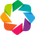

In [10]:
hv.extension('bokeh')
CPMmodels_dict = {}
for TRAINING_SES in ['ses-1','ses-2']:
    for pp in ['ALL_Basic','ALL_GS','ALL_Tedana-fastica']:
        # Keep only one colorbar in the multi-panel display to avoid redundancy.
        if pp == 'ALL_Tedana-fastica':
            remove_cbar = False
        else:
            remove_cbar = True
        for NORDIC in ['off']:
            # Plot positive-minus-negative edge selection probability matrix.
            CPMmodels_dict[(TRAINING_SES,pp,NORDIC)] = hvplot_fc(final_model[(TRAINING_SES,pp,NORDIC,'pos')]-final_model[(TRAINING_SES,pp,NORDIC,'neg')],cmap='RdBu_r', by='Network', 
              add_labels=False, colorbar_position='right', 
              major_label_overrides='regular_grid',clim=(-.8,.8),cbar_title_fontsize=14,
              net_cmap=power264_nw_cmap, cbar_title=f'Probability of contributing to CPM model for IQ', remove_colorbar=remove_cbar).opts(default_tools=["pan"]).opts(toolbar=None)


# Create Panels f - h | Predicted vs. Observed Values

Aggregate subject-level predictions across iterations, then create scatter/regression plots where marker size/color encode prediction variability.


In [11]:
predictions_xrs = {}
for TRAINING_SES in tqdm(['ses-1','ses-2'],desc='Session'):
    for pp in ['ALL_Basic','ALL_GS','ALL_Tedana-fastica']:
        for NORDIC in ['off','on']:
            # We first load one iteration to get the list of available subjects
            path = osp.join(CODE_DIR,'notebooks','cache','cpm',f'{TRAINING_SES}_{pp}_NORDIC_{NORDIC}',f'cpm_{BEHAVIOR}_rep-00000.pkl')
            aux  = pd.read_pickle(path)
            # We use this preliminary information to set the coordinates of the Xr.DataArray that will hold the predictions
            this_ses_sbj_list = list(aux['behav_obs_pred'].index)
            n_sbj = len(this_ses_sbj_list)
            predictions_xrs[(TRAINING_SES,pp,NORDIC)] = xr.DataArray(np.full((n_sbj, CPM_NUM_ITERS, 2), np.nan),
                                                                     dims=['subject','iteration','value'],
                                                                    coords={'subject':this_ses_sbj_list,
                                                                    'iteration':range(CPM_NUM_ITERS),
                                                                    'value':['observed','predicted']})
            for n_iter in tqdm(range(CPM_NUM_ITERS),desc=f'{TRAINING_SES}|{pp}|{NORDIC}', leave=False):
                # For each iteration
                zpi = str(n_iter).zfill(5)
                # Load CPM results
                try:
                    path = osp.join(CODE_DIR,'notebooks','cache','cpm',f'{TRAINING_SES}_{pp}_NORDIC_{NORDIC}',f'cpm_{BEHAVIOR}_rep-{zpi}.pkl')
                    aux = pd.read_pickle(path)
                except:
                    print(f'{TRAINING_SES}_{pp}_NORDIC_{NORDIC}',f'cpm_{BEHAVIOR}_rep-{zpi}.pkl')
                # Transfer the observed (after orthogonalization) and the predicted values to the xr.DataArray
                this_iter_output = aux['behav_obs_pred']
                predictions_xrs[(TRAINING_SES,pp,NORDIC)].loc[dict(iteration=[n_iter], value=['observed'])] = this_iter_output['nihcog_fluidcomp observed'].values[:, None, None]
                predictions_xrs[(TRAINING_SES,pp,NORDIC)].loc[dict(iteration=[n_iter], value=['predicted'])] = this_iter_output['nihcog_fluidcomp predicted (glm)'].values[:, None, None]


Session:   0%|          | 0/2 [00:00<?, ?it/s]

ses-1|ALL_Basic|off:   0%|          | 0/100 [00:00<?, ?it/s]

ses-1|ALL_Basic|on:   0%|          | 0/100 [00:00<?, ?it/s]

ses-1|ALL_GS|off:   0%|          | 0/100 [00:00<?, ?it/s]

ses-1|ALL_GS|on:   0%|          | 0/100 [00:00<?, ?it/s]

...

ses-2|ALL_Basic|on:   0%|          | 0/100 [00:00<?, ?it/s]

ses-2|ALL_GS|off:   0%|          | 0/100 [00:00<?, ?it/s]

ses-2|ALL_GS|on:   0%|          | 0/100 [00:00<?, ?it/s]

ses-2|ALL_Tedana-fastica|off:   0%|          | 0/100 [00:00<?, ?it/s]

ses-2|ALL_Tedana-fastica|on:   0%|          | 0/100 [00:00<?, ?it/s]

Create scatter plots of predicted vs. observed behavior for the three pre-processing pipelines with m-NORDIC off

In [ ]:
# Select scenario used to generate panels (f), (g), and (h).
TRAINING_SES='ses-1'
NORDIC='off'

# Keep references to saved scatter figures for final composition.
CPMpredVSobs_dict = {}
for i, pp in zip(['f','g','h'],['ALL_Basic','ALL_GS','ALL_Tedana-fastica']):
    # Compute mean and std of predicted values across all iterations (means are use for point positioning, std for dot size)
    mean_vals = predictions_xrs[(TRAINING_SES,pp,NORDIC)].mean(dim='iteration').to_dataframe(name='accuracy').reset_index().pivot(index='subject',columns='value',values='accuracy')
    stdv_vals = predictions_xrs[(TRAINING_SES,pp,NORDIC)].std(dim='iteration').to_dataframe(name='accuracy').reset_index().pivot(index='subject',columns='value',values='accuracy')
    # Gather everything into a single dataframe for plotting
    fig,ax = plt.subplots(1,1)
    df = pd.concat([mean_vals,stdv_vals],axis=1)
    df.columns=['Observed','Predicted','observed_std','predicted_std']
    df = df.infer_objects()

    sns.regplot(data=df, x='Observed', y='Predicted', ci=95, scatter=True, color='black', ax=ax)

    # Personalize the scatter plot and encode uncertainty in color/size.
    sc = ax.scatter(df['Observed'], df['Predicted'], 
                    c=df['predicted_std'], s=df['predicted_std']*30, 
                    cmap='viridis', edgecolor='black', vmin=0, vmax=1.5)

    ax.set_xlabel('Fluid IQ w/ motion (Observed)', fontsize=14, labelpad=1)
    ax.set_ylabel('Fluid IQ w/ motion (Predicted)', fontsize=14, labelpad=1)
    #ax.yaxis.set_label_coords(-0.05, 0.5)
    ax.text(-0.13, .96, f"({i})", transform=ax.transAxes,fontsize=20,
        ha="left", va="bottom", fontweight="light", clip_on=False)
    ax.set_xlim(-29,29)
    ax.set_ylim(-29,29)

    # Add a shared colorbar only to the last panel.
    if pp == 'ALL_Tedana-fastica':
        cbar = fig.colorbar(sc, ax=ax)
        cbar_ax = fig.add_axes([1.05, 0.15, 0.05, 0.82])  # [left, bottom, width, height]
        cbar    = fig.colorbar(sc, cax=cbar_ax)
        cbar.set_label('St. Dev. of Predictions across 100 CPM iters:', loc='bottom', labelpad=5, fontsize=12, fontstyle='italic')
        cbar.ax.yaxis.set_label_position('left')

    # Improve layout
    plt.tight_layout()

    # Save to disk
    # After all plotting code (and before/without plt.show())
    out_png = f"./figures/pBOLD_Figure07_{i}.png"

    plt.savefig( out_png, dpi=150, bbox_inches="tight", pad_inches=0.05)

    print(f"Saved: {out_png}")
    CPMpredVSobs_dict[i] = out_png
    plt.close()


Saved: ./figures/pBOLD_Figure05_f.png
Saved: ./figures/pBOLD_Figure05_g.png


/tmp/ipykernel_3345483/3482407157.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: ./figures/pBOLD_Figure05_h.png


# Create Final Figure Layout

Assemble all generated panels into a single HTML layout and keep a static PNG preview in the notebook.


In [13]:
# Compose all saved panel files into the final Figure 7 HTML layout.
pn.Row(
    pn.Column(
        pn.pane.PNG('./figures/pBOLD_Figure07_a.png', width=475),
        pn.pane.PNG('./figures/pBOLD_Figure07_b.png', width=475),
        styles={'border-right': '2px solid black', 'padding-left': '8px'},
        ),
    pn.Column(pn.pane.HTML("<div style='font-family: sans-serif; font-size: 24px;'>CPM Models and Observed vs. Predicted Values for Session 1</div>", width=1650, styles={'text-align': 'center'}),
              pn.Row(pn.Column(pn.pane.HTML("<div style='font-family: sans-serif; font-size: 22px;'>Basic | m-NORDIC off</div>", width=550, styles={'text-align': 'center'}),
                               pn.Row(pn.pane.HTML("<div style='font-family: sans-serif; font-size: 22px;'>(c)</div>", width=10),pn.pane.HoloViews(CPMmodels_dict[('ses-1','ALL_Basic','off')],width=500, height=500)),
                               pn.pane.PNG(CPMpredVSobs_dict['f'],width=525)),
                     pn.Column(pn.pane.HTML("<div style='font-family: sans-serif; font-size: 22px;'>GSR | m-NORDIC off</div>", width=550, styles={'text-align': 'center'}),
                               pn.Row(pn.pane.HTML("<div style='font-family: sans-serif; font-size: 22px;'>(d)</div>", width=10),pn.pane.HoloViews(CPMmodels_dict[('ses-1','ALL_GS','off')],width=500, height=500)),
                               pn.pane.PNG(CPMpredVSobs_dict['g'],width=525)),
                     pn.Column(pn.pane.HTML("<div style='font-family: sans-serif; font-size: 22px;'>Tedana | m-NORDIC off</div>", width=550, styles={'text-align': 'center'}),
                               pn.Row(pn.pane.HTML("<div style='font-family: sans-serif; font-size: 22px;'>(e)</div>", width=10),pn.pane.HoloViews(CPMmodels_dict[('ses-1','ALL_Tedana-fastica','off')],width=575, height=500)),
                               pn.pane.PNG(CPMpredVSobs_dict['h'],width=590))))).save('./figures/pBOLD_Figure07.html')


Here is the static version of the figure generated by the layout code above.

![Figure07](figures/pBOLD_Figure07.png)
